In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)


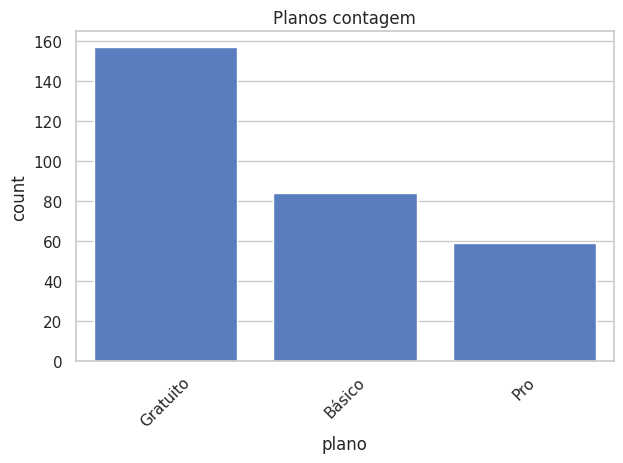

In [6]:
sns.countplot(data=df_sistema, x='plano')
plt.title('Planos contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

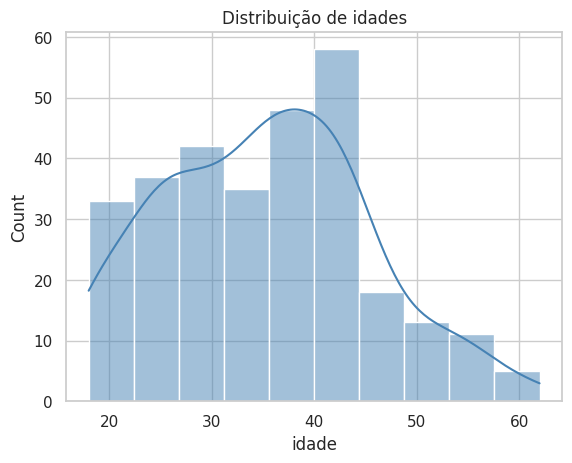

In [8]:
sns.histplot(data=df_sistema, x='idade', bins=10, kde=True, color='steelblue')
plt.title('Distribuição de idades')
plt.show()

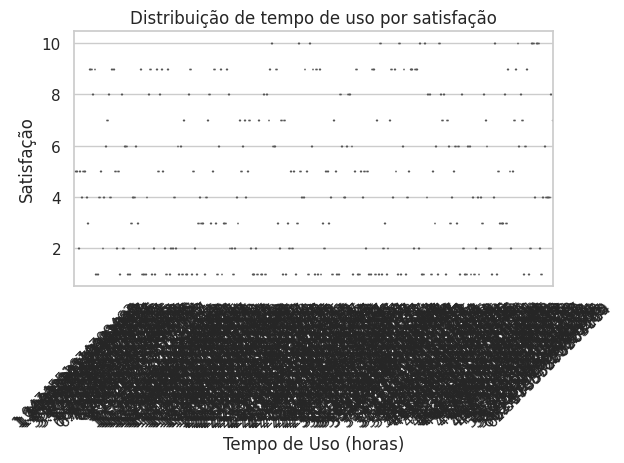

In [12]:
sns.boxplot(data=df_sistema, x='tempo_uso_horas', y='satisfacao')
plt.title('Distribuição de tempo de uso por satisfação')
plt.xlabel('Tempo de Uso (horas)')
plt.ylabel('Satisfação')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

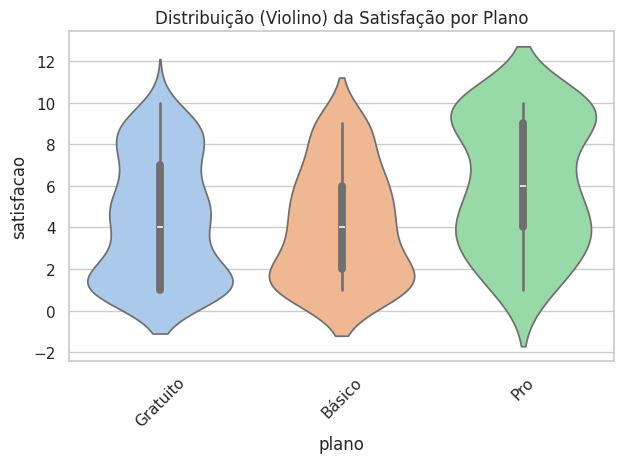

In [14]:
sns.violinplot(data=df_sistema, x='plano', y='satisfacao', hue='plano', palette='pastel', legend=False)
plt.title('Distribuição (Violino) da Satisfação por Plano')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

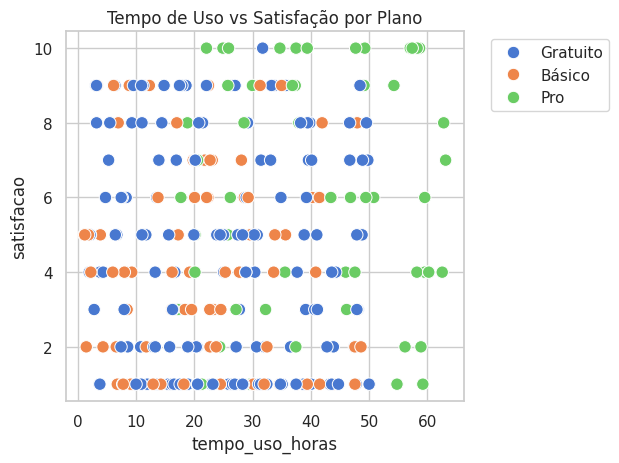

In [16]:
sns.scatterplot(data=df_sistema, x='tempo_uso_horas', y='satisfacao', hue='plano', s=80)
plt.title('Tempo de Uso vs Satisfação por Plano')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

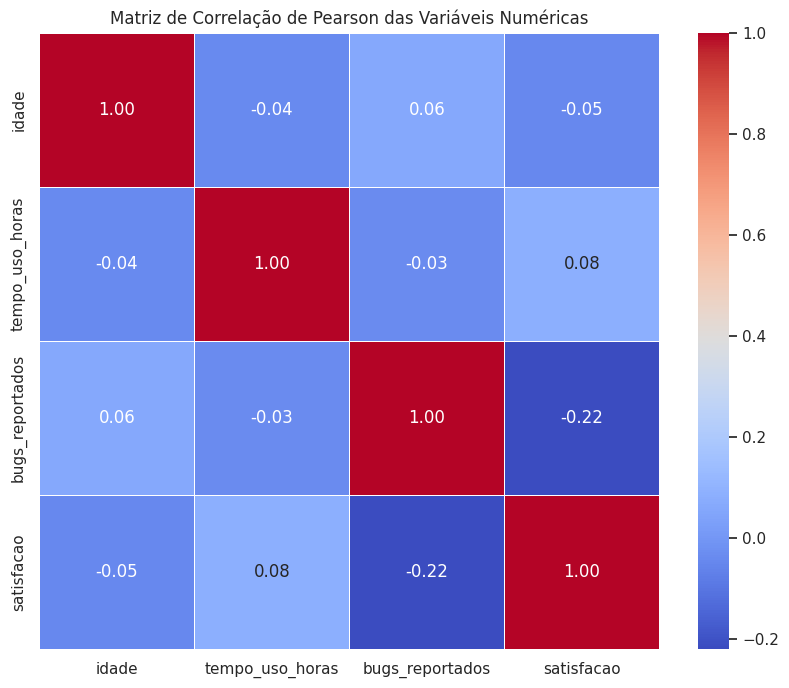

In [17]:
import numpy as np


numeric_df = df_sistema.select_dtypes(include=np.number)


correlation_matrix = numeric_df.corr(method='pearson')


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação de Pearson das Variáveis Numéricas')
plt.show()